# {Final Project Climate Change}📝

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->

### The topic I'm trying to address is climate change.

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->

### How do emissions relate to climate change trends?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->

### Emissions relate to climate change trends because greenhouse gases, mainly carbon dioxide from burning fossil fuels, deforestation, and agriculture, act as a heat trapping blanket, which directly causes global warming and climate change.

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->

Data set Files:
Carbon (CO2) emissions - https://www.kaggle.com/datasets/ravindrasinghrana/carbon-co2-emissions

Greenhouse Gas Emissions - https://www.kaggle.com/datasets/willianoliveiragibin/greenhouse-gas-emissions

Database: https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv

I will use the dataset from Our World in Data, which has a complete global data on emissions, population, and other climate-related indicators. I will store and structure this dataset in a relational database using SQLite.

I will merge the kaggle datasets using common variables like country and year as both datasets include emissions data for different countries for various years.

I will create the following tables countries, emissions, and population from Ourworld dataset and I will create a unique identifier country_id accross these tables to join them. I will then join the dataset from this to kaggle data sets using country name and year

## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

My approach is to combine emissions data from multiple datasets and analyze trends over time. I will clean and merge the datasets using common variables such as country and year. The data will be stored and queried using a SQLite database. I will then create visualizations, such as line charts, to observe how emissions change over time and compare patterns across countries. This analysis will help determine how emissions relate to climate change trends.

In [164]:
# Import necessary libraries for data manipulation and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [169]:
# Import the data from Our World in Data and store it in a DataFrame.

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

df.sample(5)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
17057,Finland,1915,FIN,3025373.0,9.249000e+09,NaN,NaN,0.106,-0.583,-84.574,...,NaN,0.418,0.000,0.001,0.001,0.0,42.885,1.302,NaN,NaN
47649,United Kingdom,1891,GBR,37809681.0,2.563354e+11,NaN,NaN,360.472,7.449,2.110,...,NaN,6.898,0.002,0.005,0.007,0.0,491.198,440.564,NaN,NaN
46448,Turks and Caicos Islands,1869,TCA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000,0.000,0.000,0.000,0.0,0.000,0.000,NaN,NaN
6380,Bolivia,1891,BOL,1484344.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,0.245,0.000,0.000,0.000,0.0,25.078,0.362,NaN,NaN
44510,Taiwan,1789,TWN,NaN,NaN,NaN,NaN,0.000,0.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Create a new DataFrame with the relevant columns for distinct countries and assign a unique country_id to each country.
countries = df[["country"]].drop_duplicates().reset_index(drop=True)

# Assign a unique country_id to each country using the index of the DataFrame. Adding 1 to start the country_id from 1 instead of 0.
countries["country_id"] = countries.index + 1

countries.sample(10)

,country,country_id
37,Burkina Faso,38
78,European Union (27),79
98,High-income countries,99
177,Oman,178
239,United Arab Emirates,240
29,Bolivia,30
217,South Sudan,218
95,Guinea-Bissau,96
141,Malta,142
176,Oceania (GCP),177


In [158]:
# Merge the country_id back to the main DataFrame

df = df.merge(countries, on="country")
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share,country_id
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
# Create a new DataFrame with the relevant columns for emissions.
population = df[["country_id", "year", "population"]]
population.head()

,country_id,year,population
0,0,1750,2802560.0
1,0,1751,NaN
2,0,1752,NaN
3,0,1753,NaN
4,0,1754,NaN


In [ ]:
# Create a new DataFrame with the relevant columns for emissions.
emissions = df[["country_id", "year", "co2", "methane"]]

emissions.sample(5)

,country_id,year,co2,methane
30894,152,2007,0.040,NaN
7051,33,1863,0.426,17.416
25325,123,1924,NaN,2.823
8698,41,1845,0.004,NaN
1355,6,1855,NaN,1.685


In [166]:
# Store the DataFrames in a SQLite database.
conn = sqlite3.connect("climate.db")

countries.to_sql("countries", conn, if_exists="replace", index=False)
emissions.to_sql("emissions", conn, if_exists="replace", index=False)
population.to_sql("population", conn, if_exists="replace", index=False)

50411

In [167]:
# Write a SQL query to join the three tables and retrieve the country name, year, CO2 emissions, methane emissions, and population.
query = """
SELECT c.country, e.year, e.co2, p.population
FROM emissions e
JOIN countries c ON e.country_id = c.country_id
JOIN population p ON e.country_id = p.country_id AND e.year = p.year
"""

result = pd.read_sql(query, conn)
print(result.head())

       country  year  co2  population
0  Afghanistan  1750  NaN   2802560.0
1  Afghanistan  1751  NaN         NaN
2  Afghanistan  1752  NaN         NaN
3  Afghanistan  1753  NaN         NaN
4  Afghanistan  1754  NaN         NaN


In [152]:
#Import data from csv files imported from Kaggle and store it in DataFrames.
Methane_final_df = pd.read_table('Methane_final.csv', sep=',')
Carbon_emissions_df = pd.read_table('Carbon_(CO2)_Emissions_by_Country.csv', sep=',')
Carbon_emissions_per_capita_df = pd.read_table('co-emissions-per-capita new.csv', sep=',')

In [57]:
Carbon_emissions_df.head()

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,01-01-2011,8930.0,0.31
1,Afghanistan,Asia,01-01-2012,8080.0,0.27
2,Afghanistan,Asia,01-01-2010,7110.0,0.25
3,Afghanistan,Asia,01-01-2019,6080.0,0.16
4,Afghanistan,Asia,01-01-2018,6070.0,0.17


In [60]:
Carbon_emissions_per_capita_df.head()

,Entity,Year,Annual CO₂ emissions (per capita)
0,Africa,1750,0
1,Andorra,1750,0
2,Asia,1750,0
3,Asia (excl. China and India),1750,0
4,Australia,1750,0


In [61]:
Methane_final_df.duplicated().sum()

np.int64(0)

In [62]:
Carbon_emissions_df.duplicated().sum()

np.int64(0)

In [63]:
Carbon_emissions_per_capita_df.duplicated().sum()

np.int64(0)

#### This shows the number of duplicate values.

#### There aren't any duplicate values.

### Are there any missing values? How are you going to deal with them?

In [ ]:
Methane_final_df.isnull().sum()

Country                   0
Region                    0
Date                      0
Kilotons of Co2           0
Metric Tons Per Capita    0
dtype: int64

In [64]:
Carbon_emissions_df.isnull().sum()

Country                   0
Region                    0
Date                      0
Kilotons of Co2           0
Metric Tons Per Capita    0
dtype: int64

In [65]:
Carbon_emissions_per_capita_df.isnull().sum()

Entity                               0
Year                                 0
Annual CO₂ emissions (per capita)    0
dtype: int64

In [42]:
print(Methane_final_df.dtypes)

Unnamed: 0      int64
region            str
country           str
emissions     float64
type              str
segment           str
reason            str
baseYear          str
notes             str
dtype: object


In [66]:
print(Carbon_emissions_df.dtypes)

Country                       str
Region                        str
Date                          str
Kilotons of Co2           float64
Metric Tons Per Capita    float64
dtype: object


In [67]:
print(Carbon_emissions_per_capita_df.dtypes)

Entity                                 str
Year                                 int64
Annual CO₂ emissions (per capita)      str
dtype: object


### Bar Chart of methane emissions per Region.

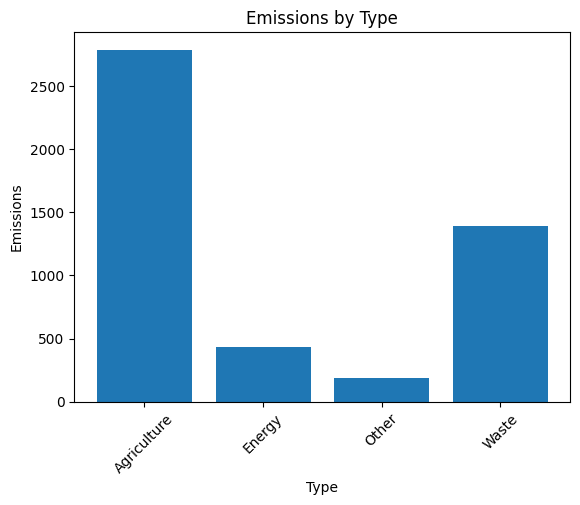

In [100]:
import pandas as pd

region_emissions = Methane_final_df.groupby('type')['emissions'].mean()

plt.bar(region_emissions.index, region_emissions.values)

plt.title("Emissions by Type")
plt.xlabel("Type")
plt.ylabel("Emissions")
plt.xticks(rotation=45)

plt.show()

### Bar chart of methane emissions trend per region.

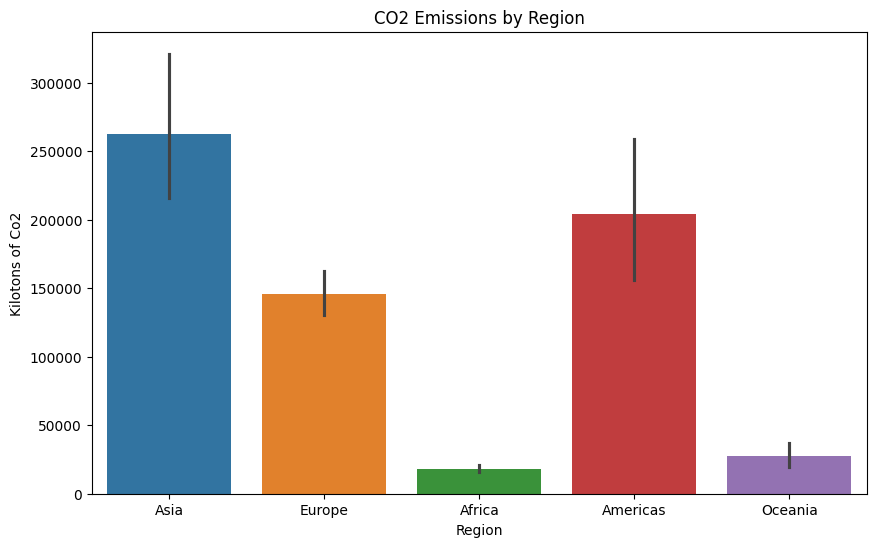

In [102]:
subset = Carbon_emissions_df[Carbon_emissions_df['Region'].notnull()]

plt.figure(figsize=(10,6))
sns.barplot(
    data=Carbon_emissions_df,
    x='Region',
    y='Kilotons of Co2',
    hue='Region'
)

plt.title("CO2 Emissions by Region")
plt.show()

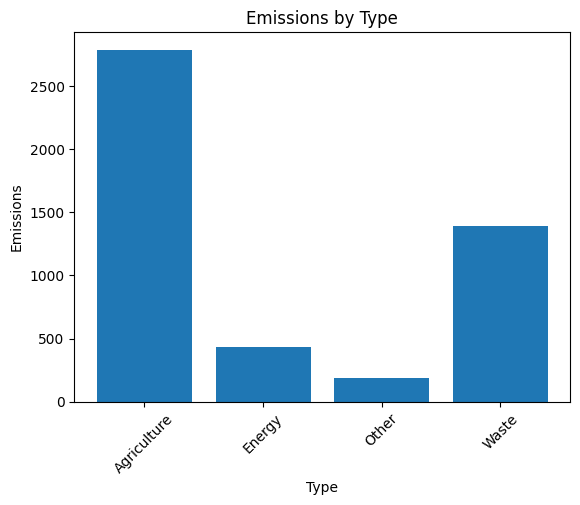

In [106]:
import pandas as pd

region_emissions = Methane_final_df.groupby('type')['emissions'].mean()

plt.bar(region_emissions.index, region_emissions.values)

plt.title("Emissions by Type")
plt.xlabel("Type")
plt.ylabel("Emissions")
plt.xticks(rotation=45)

plt.show()

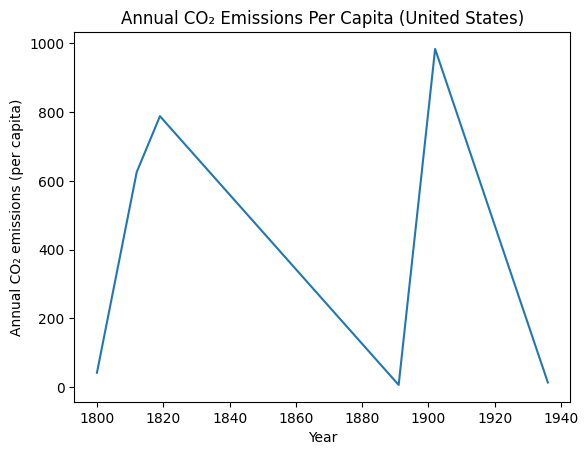

In [110]:
Carbon_emissions_per_capita_df['Annual CO₂ emissions (per capita)'] = pd.to_numeric(
    Carbon_emissions_per_capita_df['Annual CO₂ emissions (per capita)'], errors='coerce'
)
us_df = Carbon_emissions_per_capita_df[Carbon_emissions_per_capita_df['Entity'] == 'United States']

sns.lineplot(
    data=us_df,
    x='Year',
    y='Annual CO₂ emissions (per capita)'
)

plt.title("Annual CO₂ Emissions Per Capita (United States)")
plt.show()

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

In [1]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 2138 bytes to source.py
